/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


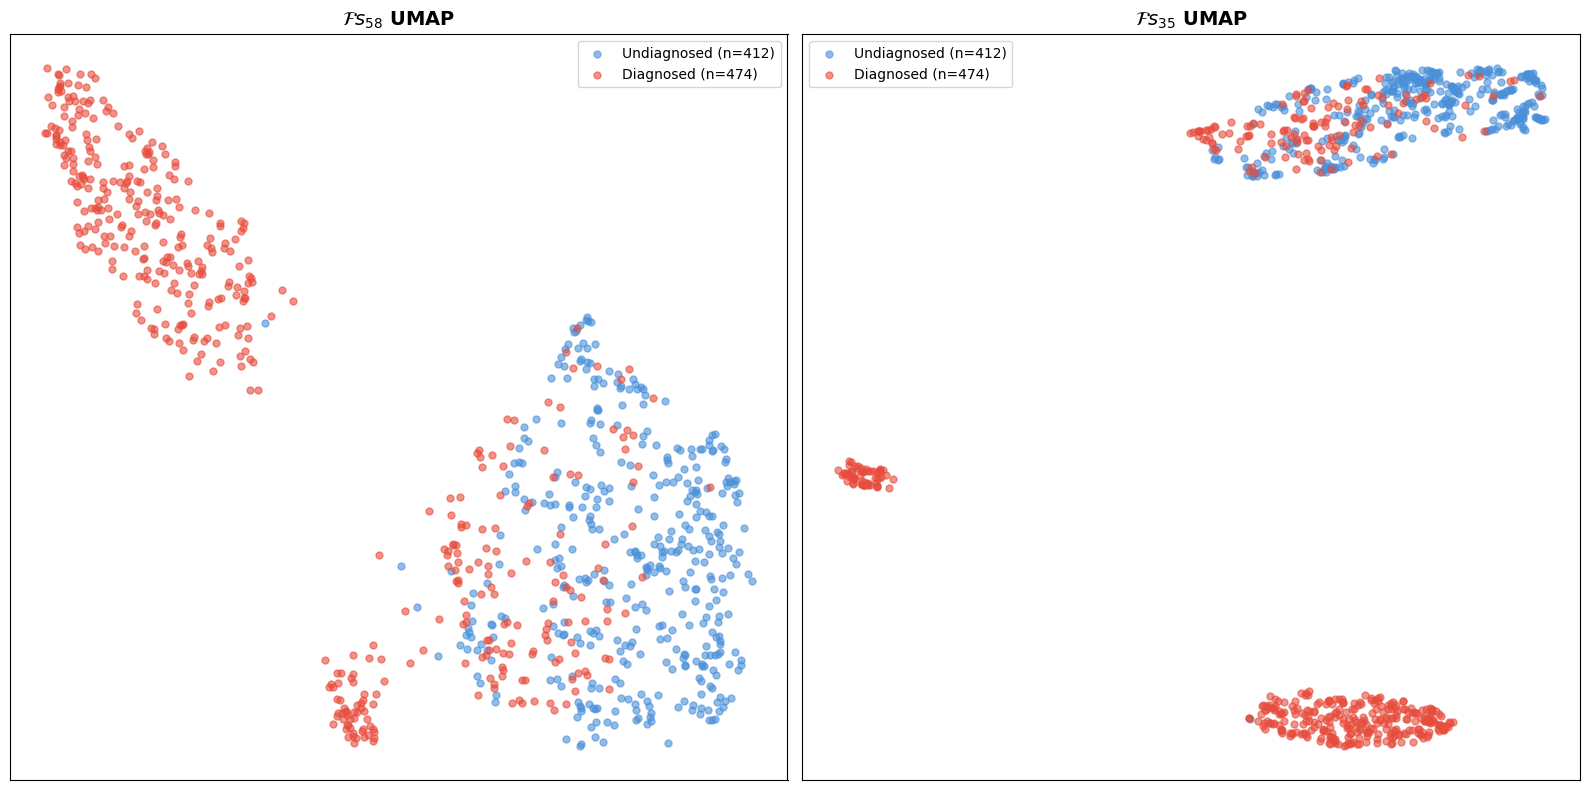

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

BASE_DIR = '/content'
FIGURES_DIR = os.path.join(BASE_DIR, 'Figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

dataset_path = os.path.join(BASE_DIR, 'dataset.xlsx')
features_35_path = os.path.join(BASE_DIR, 'FINAL_35_features_selected.csv')

df = pd.read_excel(dataset_path, engine="openpyxl")
cols_to_drop = ["Unnamed: 0", "row", "label"]
X58 = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df["label"].astype(int)

final_features = pd.read_csv(features_35_path)['feature'].tolist()
X35 = X58[final_features]

reducer58 = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='hamming',
    random_state=42
)
embedding58 = reducer58.fit_transform(X58.astype(bool))

reducer35 = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='hamming',
    random_state=42
)
embedding35 = reducer35.fit_transform(X35.astype(bool))

colors = {0: '#4A90D9', 1: '#E74C3C'}
labels_map = {0: f'Undiagnosed (n={sum(y == 0)})',
              1: f'Diagnosed (n={sum(y == 1)})'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

for cls in [0, 1]:
    mask = y == cls
    ax1.scatter(embedding58[mask, 0], embedding58[mask, 1],
                c=colors[cls], label=labels_map[cls],
                alpha=0.6, s=25)
ax1.set_title(r'$\mathcal{F}s_{58}$ UMAP', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.grid(True, alpha=0.2)

for cls in [0, 1]:
    mask = y == cls
    ax2.scatter(embedding35[mask, 0], embedding35[mask, 1],
                c=colors[cls], label=labels_map[cls],
                alpha=0.6, s=25)
ax2.set_title(r'$\mathcal{F}s_{35}$ UMAP', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.grid(True, alpha=0.2)

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'UMAP_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
